In [8]:
print("Jupyter is working!")

Jupyter is working!


In [9]:
# Unemployment Analysis with Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [11]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (267, 9)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

Data Types:
Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                           int64
 Estimated Labour Participation Rate (%)    float64
Region.1                                        str
longitude                                   float64
latitude                                    float64
dtype: object

Missing Values:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0

In [12]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [13]:
df.describe()
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
# Data Cleaning and Preprocessing

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Remove leading/trailing spaces from text columns
df["Region"] = df["Region"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()
df["Region.1"] = df["Region.1"].str.strip()

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Check data types after conversion
print(df.dtypes)

# Check missing values again
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

Region                                                str
Date                                       datetime64[us]
Frequency                                             str
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                  int64
Estimated Labour Participation Rate (%)           float64
Region.1                                              str
longitude                                         float64
latitude                                          float64
dtype: object

Missing values after preprocessing:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [15]:
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


In [16]:
# Region-wise Average Unemployment Rate

region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_avg

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64

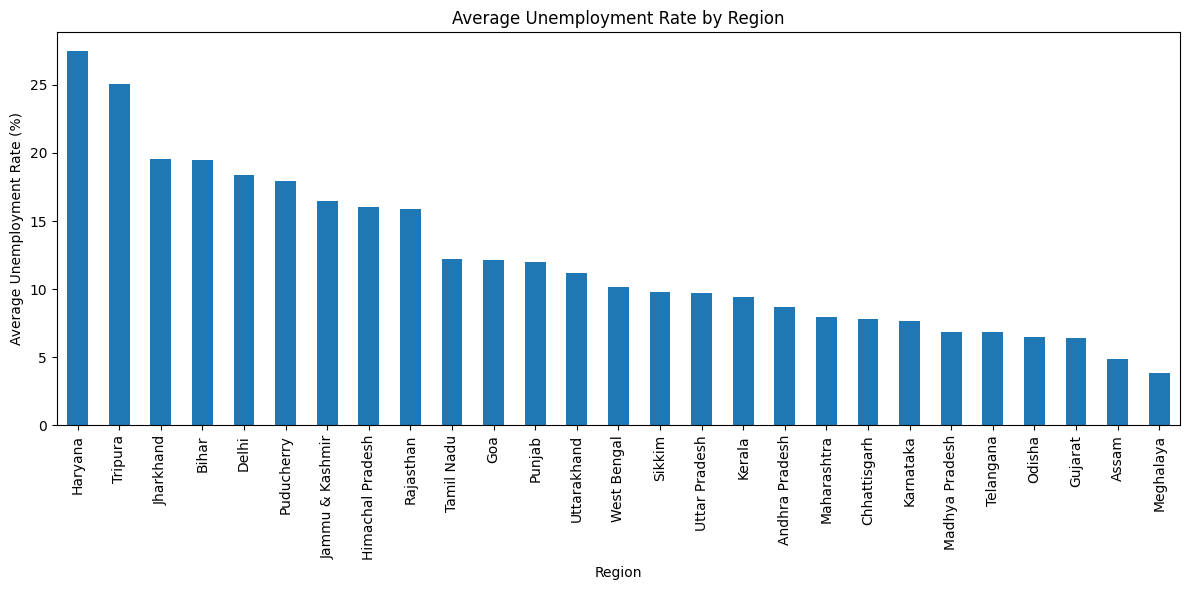

In [17]:
plt.figure(figsize=(12, 6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Observation

The average unemployment rate varies across different regions.
Some regions have significantly higher unemployment rates than
others, indicating regional differences in employment conditions.

In [18]:
# Month-wise Average Unemployment Rate

monthly_avg = (
    df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_avg

Date
2020-01     9.196538
2020-02     9.266154
2020-03    10.782593
2020-04    22.236154
2020-05    23.244444
2020-06    10.911111
2020-07     9.834444
2020-08    10.313333
2020-09     8.705926
2020-10     8.026296
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

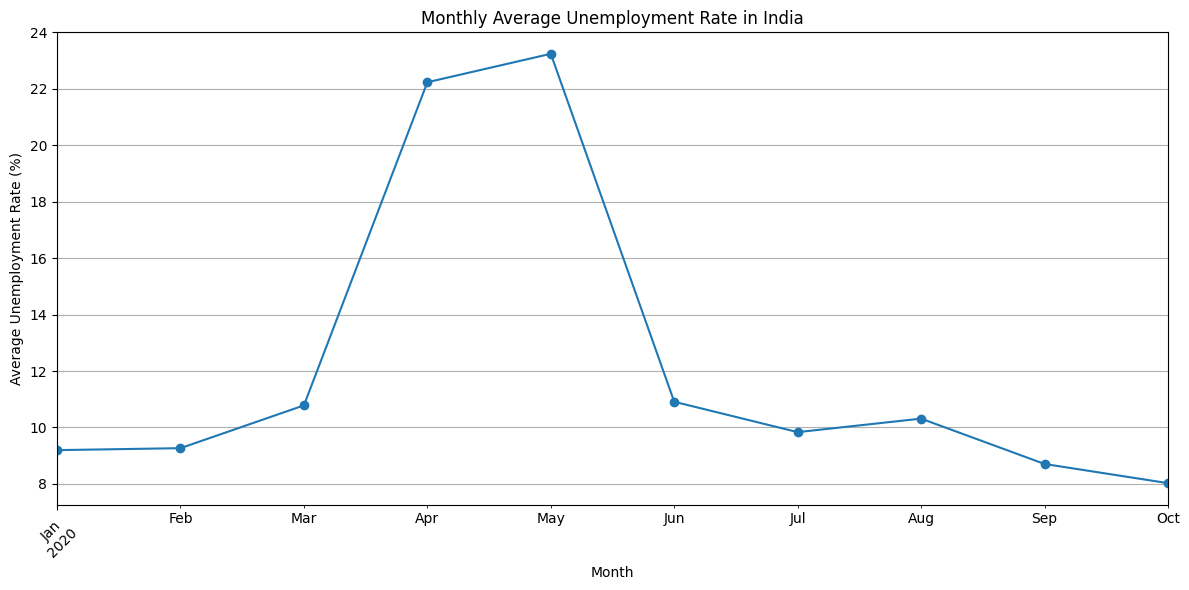

In [19]:
plt.figure(figsize=(12, 6))

monthly_avg.plot(kind="line", marker="o")

plt.title("Monthly Average Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation

The monthly unemployment rate shows noticeable changes over time.
A significant increase can be observed during the COVID-19 period,
indicating the impact of the pandemic on employment conditions.

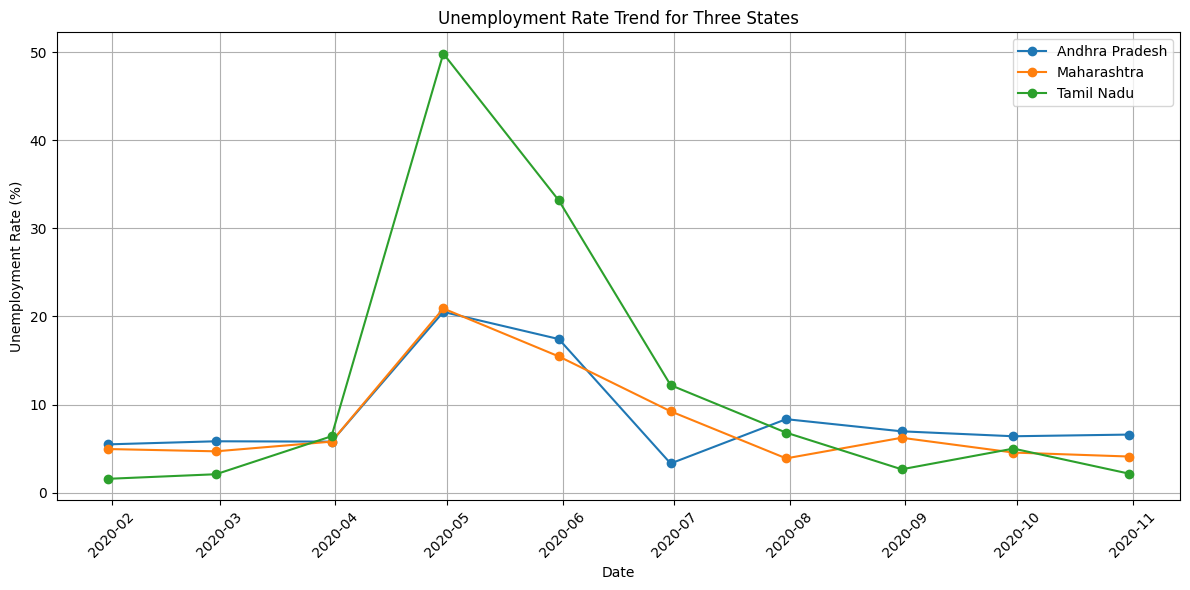

In [20]:
# Unemployment Rate Trend for Three States

selected_states = ["Andhra Pradesh", "Maharashtra", "Tamil Nadu"]

plt.figure(figsize=(12, 6))

for state in selected_states:
    state_data = df[df["Region"] == state]
    
    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Trend for Three States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Observation

The unemployment rate changes over time across the three selected
states. The trends show that unemployment was not constant and
varied across states during the study period.

In [21]:
# Top 10 Regions with Highest Average Unemployment Rate

top_10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64

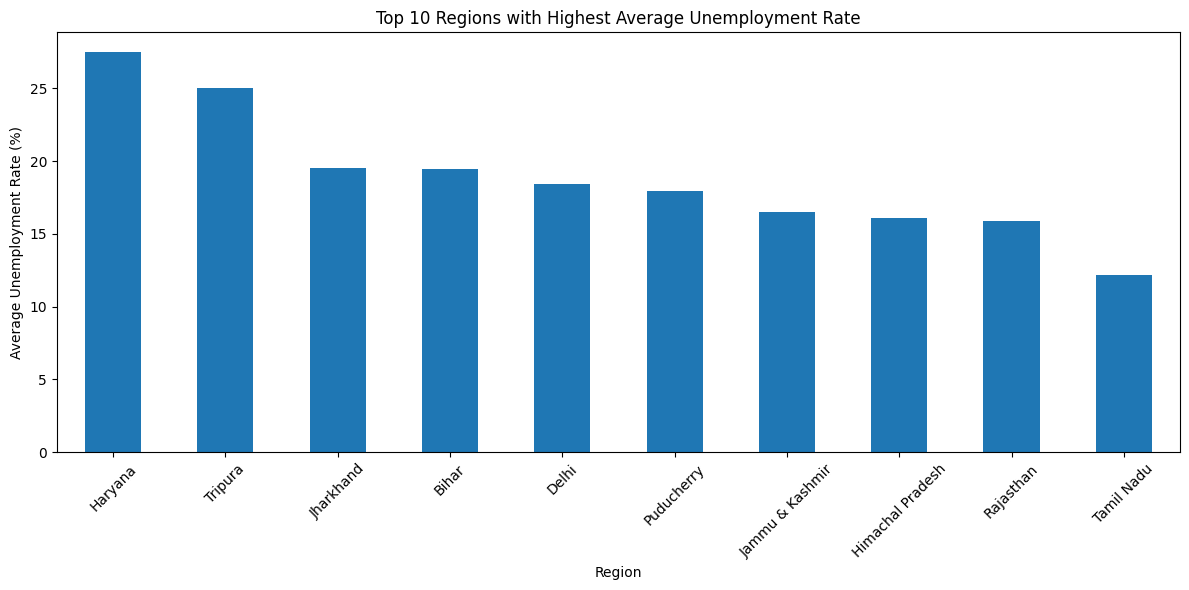

In [22]:
plt.figure(figsize=(12, 6))

top_10.plot(kind="bar")

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The top 10 regions show the highest average unemployment rates
during the study period. These regions experienced relatively
higher unemployment compared with the other regions in the dataset.

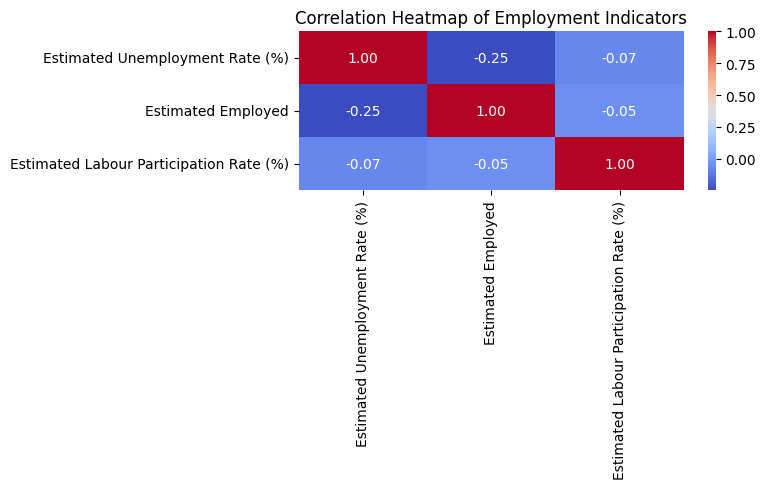

In [23]:
# Correlation Heatmap

correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Employment Indicators")
plt.tight_layout()

plt.show()

### Observation

The correlation heatmap shows the relationships between
unemployment rate, estimated employment, and labour participation
rate. The correlation values help identify whether these employment
indicators move together or in opposite directions.

In [24]:
# Pre-COVID vs Post-COVID Comparison

pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

pre_covid_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_covid_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average Unemployment Rate:",
      round(pre_covid_avg, 2), "%")

print("Post-COVID Average Unemployment Rate:",
      round(post_covid_avg, 2), "%")

Pre-COVID Average Unemployment Rate: 9.23 %
Post-COVID Average Unemployment Rate: 12.96 %


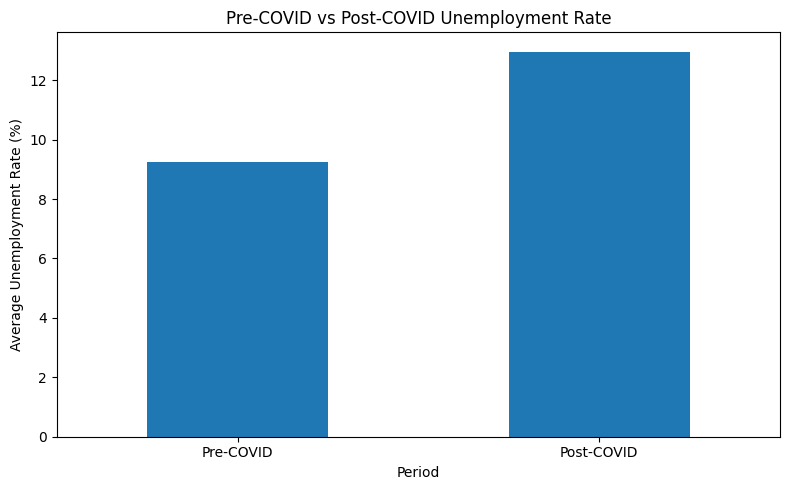

In [25]:
# Pre-COVID vs Post-COVID Bar Chart

comparison = pd.Series(
    [pre_covid_avg, post_covid_avg],
    index=["Pre-COVID", "Post-COVID"]
)

plt.figure(figsize=(8, 5))

comparison.plot(kind="bar")

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Observation

The comparison shows a difference between the average unemployment
rate before and after the start of the COVID-19 period. The change
indicates the impact of the pandemic period on unemployment in India.

# Conclusion

- Unemployment rates varied considerably across different regions.
- Monthly analysis showed changes in unemployment over time.
- The three-state comparison showed different unemployment trends
  across states.
- The top 10 regions had relatively higher average unemployment rates.
- The correlation analysis showed relationships among key employment
  indicators.
- The Pre-COVID and Post-COVID comparison showed a change in
  unemployment during the COVID-19 period.